# Telco Customer Churn for Marketing Retention

This notebook frames churn prediction as a marketing and retention project.

## Goal

Predict which customers are likely to churn and support a retention strategy that maximizes business value, not just model accuracy.

## What this notebook covers

- Data loading and cleaning
- Exploratory data analysis
- Baseline modeling with Logistic Regression
- Stronger modeling with XGBoost
- ROC-AUC and PR-AUC evaluation
- Threshold optimization for retention use cases
- Simple profit/ROI analysis
- Feature importance and business interpretation


## Setup

If `xgboost` is missing in this environment, uncomment the install command below and run it once.


In [36]:
# %pip install xgboost seaborn scikit-learn matplotlib pandas numpy

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## Step 1: Load Data

Place `Telco-Customer-Churn.csv` in `data/` under this notebooks folder, or update `DATA_PATH` below.


In [37]:
DATA_PATH = Path("data/Telco-Customer-Churn.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Add the dataset to the notebooks folder or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Basic Cleaning

We convert the target to binary, fix `TotalCharges`, and remove rows where the charge value is missing after conversion.


In [38]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()

print(df.shape)
df.head()


(7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Step 3: EDA

A few interview-friendly checks:

- What is the churn rate?
- Is the dataset imbalanced?
- Which business variables look associated with churn?


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


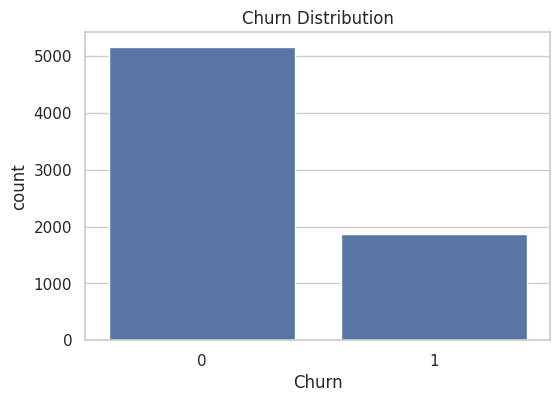

Average MonthlyCharges by churn:
Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64


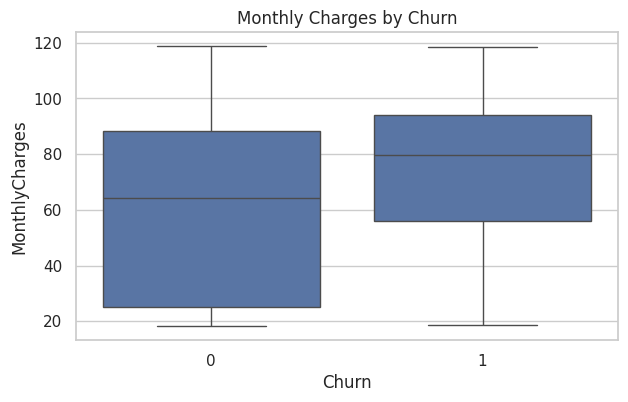

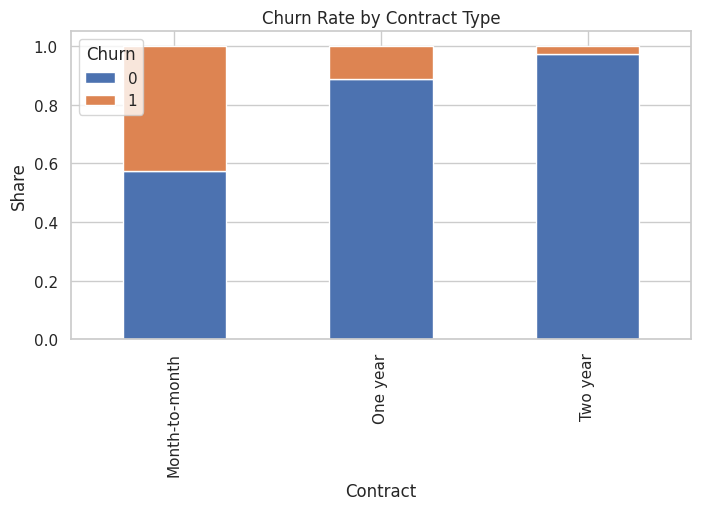

In [39]:
churn_rate = df["Churn"].value_counts(normalize=True).sort_index()
print(churn_rate)

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

print("Average MonthlyCharges by churn:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

plt.figure(figsize=(7, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

plt.figure(figsize=(8, 4))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
contract_churn.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Churn Rate by Contract Type")
plt.ylabel("Share")
plt.legend(title="Churn")
plt.show()


### Interview talking points

- The dataset is typically imbalanced, with churn materially lower than non-churn.
- Higher `MonthlyCharges` often correlate with more churn risk.
- Month-to-month contracts tend to show meaningfully higher churn than long-term contracts.
- These patterns support targeted retention offers for high-risk, high-value customers.


## Step 4: Feature Engineering

We drop `customerID`, then keep numeric and categorical columns separate so we can use preprocessing pipelines cleanly.


In [40]:
df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)
y = df["Churn"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## Step 5: Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(X_train.shape, X_test.shape)


(5625, 19) (1407, 19)


## Step 6: Logistic Regression Baseline

A baseline is important in interviews because it shows you can compare a simple, interpretable model against a more powerful one.


In [42]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

lr_model.fit(X_train, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]


## Step 7: XGBoost Model

We fit XGBoost on an encoded feature matrix so it can handle the transformed inputs directly.


In [43]:
X_train_xgb = pd.get_dummies(X_train, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, drop_first=True)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb_model.fit(X_train_xgb, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]


## Step 8: Evaluation

For imbalanced churn problems, ROC-AUC is useful, but PR-AUC is especially important because it reflects how well we rank likely churners.


In [44]:
print("LR ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_lr), 4))
print("XGB ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))
print("LR PR-AUC:", round(average_precision_score(y_test, y_pred_proba_lr), 4))
print("XGB PR-AUC:", round(average_precision_score(y_test, y_pred_proba_xgb), 4))


LR ROC-AUC: 0.8361
XGB ROC-AUC: 0.8348
LR PR-AUC: 0.623
XGB PR-AUC: 0.6479


## Step 9: Threshold Optimization

Instead of using the default threshold of `0.5`, we lower it to capture more churners. This is a business decision: higher recall can be more valuable when missing a churner is expensive.


In [45]:
threshold = 0.30
y_pred = (y_pred_proba_xgb > threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


[[760 273]
 [ 84 290]]
              precision    recall  f1-score   support

           0      0.900     0.736     0.810      1033
           1      0.515     0.775     0.619       374

    accuracy                          0.746      1407
   macro avg      0.708     0.756     0.714      1407
weighted avg      0.798     0.746     0.759      1407



## Step 10: Business Cost Function

Here we define a simple profit logic:

- True Positive: we correctly identify a churner and save them with a retention action
- False Negative: we miss a churner and lose that customer
- False Positive: we offer an unnecessary retention incentive


In [46]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

profit = tp * 100 + tn * 0 + fp * (-10) + fn * (-100)

print({"tn": tn, "fp": fp, "fn": fn, "tp": tp})
print("Profit:", profit)


{'tn': 760, 'fp': 273, 'fn': 84, 'tp': 290}
Profit: 17870


### Optional: search for the best threshold by business value

This is often stronger than manually picking `0.30` because it shows decision optimization, not just model fitting.


In [47]:
threshold_results = []

for t in np.arange(0.10, 0.91, 0.05):
    preds = (y_pred_proba_xgb > t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    profit_ = tp_ * 100 + fp_ * (-10) + fn_ * (-100)
    threshold_results.append(
        {
            "threshold": round(float(t), 2),
            "tp": tp_,
            "fp": fp_,
            "fn": fn_,
            "profit": profit_,
        }
    )

threshold_df = pd.DataFrame(threshold_results).sort_values("profit", ascending=False)
threshold_df.head(10)


,threshold,tp,fp,fn,profit
0,0.10,351,525,23,27550
1,0.15,331,421,43,24590
2,0.20,314,370,60,21700
3,0.25,302,316,72,19840
4,0.30,290,273,84,17870
5,0.35,272,229,102,14710
6,0.40,247,175,127,10250
7,0.45,225,147,149,6130
8,0.50,198,114,176,1060
9,0.55,173,92,201,-3720


## Step 11: Feature Importance

This helps connect the model back to marketing strategy and customer retention actions.


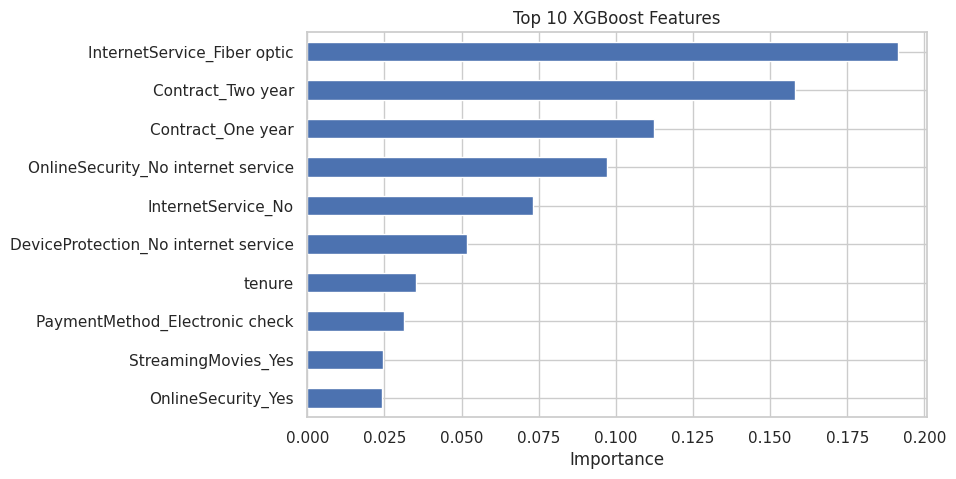

OnlineSecurity_Yes                      0.024354
StreamingMovies_Yes                     0.024569
PaymentMethod_Electronic check          0.031512
tenure                                  0.035272
DeviceProtection_No internet service    0.051790
InternetService_No                      0.073071
OnlineSecurity_No internet service      0.097204
Contract_One year                       0.112522
Contract_Two year                       0.158184
InternetService_Fiber optic             0.191326
dtype: float32

In [48]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
top_features = importances.sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(8, 5))
top_features.plot(kind="barh")
plt.title("Top 10 XGBoost Features")
plt.xlabel("Importance")
plt.show()

top_features


## Step 11B: Class Imbalance Handling (XGBoost)

To make churn detection more robust, we explicitly weight the positive class using `scale_pos_weight = negative / positive`.


In [49]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print({'neg_count': int(neg_count), 'pos_count': int(pos_count), 'scale_pos_weight': round(float(scale_pos_weight), 2)})

xgb_model_balanced = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)

xgb_model_balanced.fit(X_train_xgb, y_train)
y_pred_proba_xgb_balanced = xgb_model_balanced.predict_proba(X_test_xgb)[:, 1]

print('XGB (balanced) ROC-AUC:', round(roc_auc_score(y_test, y_pred_proba_xgb_balanced), 4))
print('XGB (balanced) PR-AUC:', round(average_precision_score(y_test, y_pred_proba_xgb_balanced), 4))


{'neg_count': 4130, 'pos_count': 1495, 'scale_pos_weight': 2.76}
XGB (balanced) ROC-AUC: 0.8329
XGB (balanced) PR-AUC: 0.6482


## Step 11C: Probability Calibration

AUC measures ranking quality. Calibration checks whether predicted probabilities are trustworthy for business decisioning.


> **Side note (calibration method choice):**
> - **Isotonic** is flexible and often better when you have enough data.
> - **Platt scaling** (`method="sigmoid"`) is more stable on smaller datasets.
> - In interviews: mention you would compare both with **Brier score** and pick the more stable holdout result.


In [50]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

xgb_for_calibration = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)

calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_for_calibration,
    method='isotonic',
    cv=3,
)

calibrated_xgb.fit(X_train_xgb, y_train)
y_pred_proba_xgb_calibrated = calibrated_xgb.predict_proba(X_test_xgb)[:, 1]

print('Brier (uncalibrated):', round(brier_score_loss(y_test, y_pred_proba_xgb_balanced), 4))
print('Brier (calibrated):', round(brier_score_loss(y_test, y_pred_proba_xgb_calibrated), 4))
print('ROC-AUC (calibrated):', round(roc_auc_score(y_test, y_pred_proba_xgb_calibrated), 4))
print('PR-AUC (calibrated):', round(average_precision_score(y_test, y_pred_proba_xgb_calibrated), 4))


Brier (uncalibrated): 0.1697
Brier (calibrated): 0.1392
ROC-AUC (calibrated): 0.8368
PR-AUC (calibrated): 0.6506


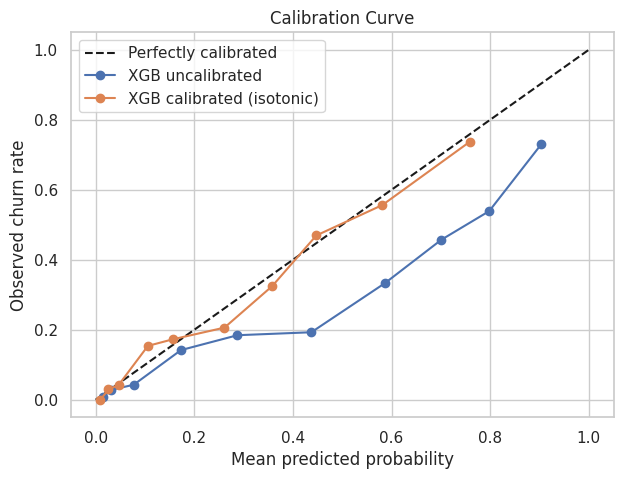

In [51]:
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_pred_proba_xgb_balanced, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_xgb_calibrated, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='XGB uncalibrated')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='XGB calibrated (isotonic)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed churn rate')
plt.title('Calibration Curve')
plt.legend()
plt.show()


## Step 11D: SHAP Explainability

SHAP provides local and global explanations for why customers are scored as likely churners.


> **Side note (SHAP caveat):**
> SHAP explains *model behavior* (associations learned by the model), not causal effect.
> Use it to support action design, but validate interventions with experiments or controlled rollouts.


In [52]:
# If SHAP is not installed in your notebook environment, uncomment and run once:
# %pip install shap

try:
    import shap

    shap_sample = X_test_xgb.sample(n=min(500, len(X_test_xgb)), random_state=42)
    explainer = shap.TreeExplainer(xgb_model_balanced)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(shap_values, shap_sample, plot_type='bar')
except ModuleNotFoundError:
    print('SHAP is not installed. Run `%pip install shap` and rerun this cell.')


SHAP is not installed. Run `%pip install shap` and rerun this cell.


## Step 11E: Risk Segmentation (Top 20% Capture)

We rank customers by churn probability and check what fraction of true churners is captured in the top-risk segment.


> **Side note (business interpretation):**
> `capture_rate_top20pct` answers: *"If operations can only target 20% of customers, what share of all churners do we catch?"*
> This ties model ranking directly to campaign capacity and expected retention impact.


In [53]:
score_col = 'score_calibrated'
scores_for_segmentation = y_pred_proba_xgb_calibrated if 'y_pred_proba_xgb_calibrated' in globals() else y_pred_proba_xgb_balanced

risk_df = X_test.copy().reset_index(drop=True)
risk_df[score_col] = scores_for_segmentation
risk_df['actual_churn'] = y_test.reset_index(drop=True)

risk_df = risk_df.sort_values(score_col, ascending=False).reset_index(drop=True)
top_n = max(1, int(len(risk_df) * 0.20))
top_segment = risk_df.head(top_n)

total_churners = int(risk_df['actual_churn'].sum())
captured_churners = int(top_segment['actual_churn'].sum())
capture_rate = captured_churners / total_churners if total_churners > 0 else 0

print({'top_segment_size': top_n, 'total_churners': total_churners, 'captured_churners_top20pct': captured_churners, 'capture_rate_top20pct': round(capture_rate, 4)})

display_cols = [c for c in ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', score_col, 'actual_churn'] if c in top_segment.columns]
top_segment[display_cols].head(15)


{'top_segment_size': 281, 'total_churners': 374, 'captured_churners_top20pct': 184, 'capture_rate_top20pct': 0.492}


,tenure,Contract,MonthlyCharges,TotalCharges,score_calibrated,actual_churn
0,1,Month-to-month,95.10,95.10,0.990991,1
1,1,Month-to-month,85.05,85.05,0.990991,1
2,3,Month-to-month,100.95,329.95,0.863566,1
3,3,Month-to-month,96.60,291.90,0.861857,1
4,1,Month-to-month,77.15,77.15,0.861857,1
5,7,Month-to-month,99.25,665.45,0.861857,1
6,4,Month-to-month,89.20,346.20,0.858500,1
7,1,Month-to-month,79.35,79.35,0.854557,1
8,3,Month-to-month,94.85,335.75,0.852847,0
9,3,Month-to-month,85.30,264.80,0.844595,1


## Step 11F: Leakage And Overfitting Check

We compare train vs. test AUC. Large gaps can indicate overfitting, and we also keep an explicit statement on leakage control.


> **Side note (threshold governance):**
> The chosen threshold should be reviewed regularly (for example monthly/quarterly) because churn base rates, campaign cost, and incentive effectiveness change over time.


In [54]:
# Train vs test gap checks
lr_train_proba = lr_model.predict_proba(X_train)[:, 1]
lr_test_proba = y_pred_proba_lr

xgb_train_proba = xgb_model_balanced.predict_proba(X_train_xgb)[:, 1]
xgb_test_proba = y_pred_proba_xgb_balanced

train_test_auc = pd.DataFrame(
    {
        'model': ['LogisticRegression', 'XGBoostBalanced'],
        'train_roc_auc': [roc_auc_score(y_train, lr_train_proba), roc_auc_score(y_train, xgb_train_proba)],
        'test_roc_auc': [roc_auc_score(y_test, lr_test_proba), roc_auc_score(y_test, xgb_test_proba)],
    }
)
train_test_auc['auc_gap'] = train_test_auc['train_roc_auc'] - train_test_auc['test_roc_auc']
train_test_auc.round(4)


,model,train_roc_auc,test_roc_auc,auc_gap
0,LogisticRegression,0.8506,0.8361,0.0145
1,XGBoostBalanced,0.9050,0.8329,0.0722


### Leakage control note

Leakage check used in this notebook:
- Features are based on customer attributes available at scoring time.
- `Churn` is only used as the target label and is excluded from input features.
- Train-test split is done before model fitting, and all metrics are reported on holdout test data.


> **Side note (common leakage traps):**
> - Post-churn events or outcomes embedded in features.
> - Aggregations computed with future data windows.
> - Features that are administrative proxies for cancellation status.


## Reproducibility Note (DVC)

For production-style data and experiment versioning, add DVC to this workflow:
- DVC Quick Start: https://doc.dvc.org/start


> **Side note (monitoring in production):**
> In addition to model metrics, monitor:
> - **Calibration drift** (probability quality decay),
> - **Class balance drift** (churn prevalence shift),
> - **Feature distribution drift** on key drivers.


## Step 11G: Uplift Modeling (Next Level)

Uplift modeling estimates **incremental impact of treatment** (for example, a retention offer) instead of only predicting churn risk.

In this notebook:
- If treatment/outcome columns exist, we use them directly.
- Otherwise, we build a **clearly labeled synthetic demo** so the uplift workflow is still interview-ready.


> **Beginner note:**
> Think of uplift as **"who should we contact"** rather than **"who is risky"**.
> A high-risk customer may still be a poor target if treatment does not change their behavior.


> **Side note (interview framing):**
> Risk modeling answers *"who will churn?"*.
> Uplift modeling answers *"who will change behavior if we intervene?"*.
> Prioritize outreach by uplift score when campaign budget is limited.


In [55]:
# Auto-detect treatment and outcome columns; fallback to synthetic demo if unavailable
possible_treatment_cols = ['treatment', 'is_treated', 'offer', 'retention_offer', 'campaign_flag']
possible_outcome_cols = ['retained', 'conversion', 'responded', 'response', 'churn', 'Churn']

treatment_col = next((c for c in possible_treatment_cols if c in df.columns), None)
outcome_col = next((c for c in possible_outcome_cols if c in df.columns), None)

use_synthetic_uplift_demo = treatment_col is None or outcome_col is None

if use_synthetic_uplift_demo:
    print('No treatment/outcome columns detected. Using synthetic uplift demo for workflow illustration.')

    uplift_df = X.copy().reset_index(drop=True)

    # Baseline stay probability from the existing logistic model
    base_churn_prob = lr_model.predict_proba(X)[:, 1]
    base_stay_prob = np.clip(1 - base_churn_prob, 0.01, 0.99)

    # Simulated heterogeneous treatment effect (true uplift) for demonstration
    true_tau = np.full(len(uplift_df), 0.02)
    if 'Contract' in uplift_df.columns:
        true_tau += (uplift_df['Contract'].astype(str).str.contains('Month', case=False, na=False)).astype(float) * 0.08
    if 'MonthlyCharges' in uplift_df.columns:
        true_tau += (uplift_df['MonthlyCharges'].fillna(0).astype(float) > 70).astype(float) * 0.04
    true_tau = np.clip(true_tau, 0.0, 0.25)

    rng = np.random.default_rng(42)
    uplift_df['treatment'] = rng.binomial(1, 0.5, len(uplift_df))

    p_stay_treated = np.clip(base_stay_prob + true_tau, 0.01, 0.99)
    p_stay_control = base_stay_prob

    p_observed = np.where(uplift_df['treatment'] == 1, p_stay_treated, p_stay_control)
    uplift_df['outcome'] = rng.binomial(1, p_observed)

    treatment_col = 'treatment'
    outcome_col = 'outcome'
else:
    print(f'Using observed uplift columns: treatment={treatment_col}, outcome={outcome_col}')
    uplift_df = df.copy().reset_index(drop=True)

    # Normalize a churn label to "stay" outcome for uplift interpretation
    if outcome_col.lower() == 'churn':
        uplift_df[outcome_col] = (uplift_df[outcome_col].astype(str).str.lower() == 'no').astype(int)


No treatment/outcome columns detected. Using synthetic uplift demo for workflow illustration.


In [56]:
# Build T-learner uplift model (separate models for treated and control)
feature_cols = [c for c in uplift_df.columns if c not in [treatment_col, outcome_col, 'customerID']]
X_uplift = uplift_df[feature_cols]
T_uplift = uplift_df[treatment_col].astype(int)
Y_uplift = uplift_df[outcome_col].astype(int)

X_uplift_ohe = pd.get_dummies(X_uplift, drop_first=True)

X_uplift_train, X_uplift_test, T_uplift_train, T_uplift_test, Y_uplift_train, Y_uplift_test = train_test_split(
    X_uplift_ohe,
    T_uplift,
    Y_uplift,
    test_size=0.2,
    random_state=42,
)

train_treated_mask = T_uplift_train == 1
train_control_mask = T_uplift_train == 0

uplift_model_treated = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

uplift_model_control = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

uplift_model_treated.fit(X_uplift_train[train_treated_mask], Y_uplift_train[train_treated_mask])
uplift_model_control.fit(X_uplift_train[train_control_mask], Y_uplift_train[train_control_mask])

p_treated = uplift_model_treated.predict_proba(X_uplift_test)[:, 1]
p_control = uplift_model_control.predict_proba(X_uplift_test)[:, 1]
uplift_score = p_treated - p_control

uplift_eval = pd.DataFrame(
    {
        'uplift_score': uplift_score,
        'treatment': T_uplift_test.values,
        'outcome': Y_uplift_test.values,
    }
).sort_values('uplift_score', ascending=False).reset_index(drop=True)

uplift_eval.head()


,uplift_score,treatment,outcome
0,0.488262,0,0
1,0.472820,1,1
2,0.470325,1,1
3,0.463035,1,1
4,0.449354,0,1


In [57]:
# Incremental lift table and top-20% uplift summary
rows = []
for frac in np.arange(0.1, 1.01, 0.1):
    n = max(1, int(len(uplift_eval) * frac))
    seg = uplift_eval.head(n)

    treated_seg = seg[seg['treatment'] == 1]
    control_seg = seg[seg['treatment'] == 0]

    treated_rate = treated_seg['outcome'].mean() if len(treated_seg) > 0 else np.nan
    control_rate = control_seg['outcome'].mean() if len(control_seg) > 0 else np.nan

    incremental_lift = (treated_rate - control_rate) * len(seg) if (not np.isnan(treated_rate) and not np.isnan(control_rate)) else np.nan

    rows.append(
        {
            'top_fraction': round(float(frac), 2),
            'segment_size': int(n),
            'treated_rate': treated_rate,
            'control_rate': control_rate,
            'incremental_lift': incremental_lift,
        }
    )

uplift_lift_table = pd.DataFrame(rows)

# Top-20% action summary
top20 = uplift_eval.head(max(1, int(len(uplift_eval) * 0.20)))
t20_treated = top20[top20['treatment'] == 1]
t20_control = top20[top20['treatment'] == 0]
t20_treated_rate = t20_treated['outcome'].mean() if len(t20_treated) > 0 else np.nan
t20_control_rate = t20_control['outcome'].mean() if len(t20_control) > 0 else np.nan
t20_incremental_lift = (t20_treated_rate - t20_control_rate) * len(top20) if (not np.isnan(t20_treated_rate) and not np.isnan(t20_control_rate)) else np.nan

print(
    {
        'top20_segment_size': int(len(top20)),
        'top20_treated_rate': None if np.isnan(t20_treated_rate) else round(float(t20_treated_rate), 4),
        'top20_control_rate': None if np.isnan(t20_control_rate) else round(float(t20_control_rate), 4),
        'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else round(float(t20_incremental_lift), 2),
    }
)

uplift_lift_table


{'top20_segment_size': 281, 'top20_treated_rate': 0.6183, 'top20_control_rate': 0.52, 'top20_incremental_lift': 27.63}


,top_fraction,segment_size,treated_rate,control_rate,incremental_lift
0,0.1,140,0.590909,0.472973,16.511057
1,0.2,281,0.618321,0.520000,27.628092
2,0.3,422,0.661692,0.502262,67.279080
3,0.4,562,0.667984,0.556634,62.578636
4,0.5,703,0.695652,0.603675,64.660276
5,0.6,844,0.732824,0.645233,73.927320
6,0.7,984,0.758170,0.683810,73.170644
7,0.8,1125,0.788679,0.721008,76.129697
8,0.9,1266,0.801347,0.738095,80.076479
9,1.0,1407,0.802115,0.724832,108.736603


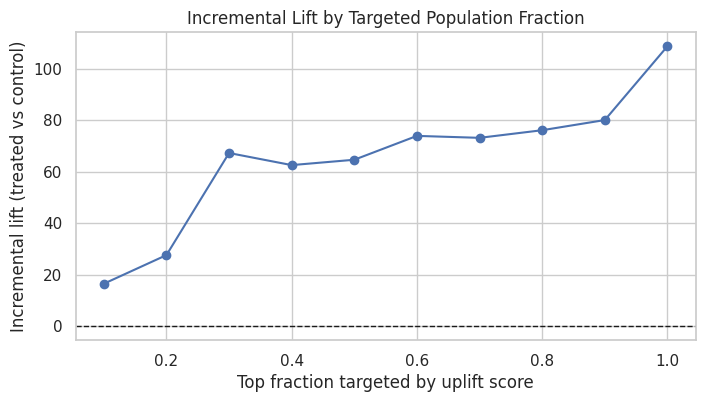

In [58]:
plt.figure(figsize=(8, 4))
plt.plot(uplift_lift_table['top_fraction'], uplift_lift_table['incremental_lift'], marker='o')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Incremental Lift by Targeted Population Fraction')
plt.xlabel('Top fraction targeted by uplift score')
plt.ylabel('Incremental lift (treated vs control)')
plt.show()


## Step 11H: Alternative Uplift Learners (S-Learner, X-Learner, Causal Forest)

Below are additional uplift strategies often discussed in advanced interviews.


> **Side note (when to use which):**
> - **S-learner**: simplest operational baseline, one model with treatment as a feature.
> - **X-learner**: often stronger when treatment effects are heterogeneous and treatment/control sizes are imbalanced.
> - **Uplift Trees / Causal Forests**: useful for nonlinearity and interaction-rich treatment effects.


In [59]:
def build_uplift_lift_table(scores, treatment, outcome):
    eval_df = pd.DataFrame(
        {
            'uplift_score': np.asarray(scores),
            'treatment': np.asarray(treatment).astype(int),
            'outcome': np.asarray(outcome).astype(int),
        }
    ).sort_values('uplift_score', ascending=False).reset_index(drop=True)

    rows = []
    for frac in np.arange(0.1, 1.01, 0.1):
        n = max(1, int(len(eval_df) * frac))
        seg = eval_df.head(n)

        treated_seg = seg[seg['treatment'] == 1]
        control_seg = seg[seg['treatment'] == 0]

        treated_rate = treated_seg['outcome'].mean() if len(treated_seg) > 0 else np.nan
        control_rate = control_seg['outcome'].mean() if len(control_seg) > 0 else np.nan

        incremental_lift = (treated_rate - control_rate) * len(seg) if (not np.isnan(treated_rate) and not np.isnan(control_rate)) else np.nan

        rows.append(
            {
                'top_fraction': round(float(frac), 2),
                'segment_size': int(n),
                'treated_rate': treated_rate,
                'control_rate': control_rate,
                'incremental_lift': incremental_lift,
            }
        )

    table = pd.DataFrame(rows)

    top20 = eval_df.head(max(1, int(len(eval_df) * 0.20)))
    t20_treated = top20[top20['treatment'] == 1]
    t20_control = top20[top20['treatment'] == 0]
    t20_treated_rate = t20_treated['outcome'].mean() if len(t20_treated) > 0 else np.nan
    t20_control_rate = t20_control['outcome'].mean() if len(t20_control) > 0 else np.nan
    t20_incremental_lift = (t20_treated_rate - t20_control_rate) * len(top20) if (not np.isnan(t20_treated_rate) and not np.isnan(t20_control_rate)) else np.nan

    summary = {
        'top20_segment_size': int(len(top20)),
        'top20_treated_rate': None if np.isnan(t20_treated_rate) else round(float(t20_treated_rate), 4),
        'top20_control_rate': None if np.isnan(t20_control_rate) else round(float(t20_control_rate), 4),
        'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else round(float(t20_incremental_lift), 2),
    }

    return summary, table


### S-learner


> **Beginner note:**
> S-learner is the easiest uplift model to understand:
> - Train one model,
> - Add treatment as an input feature,
> - Predict once as treated and once as control,
> - Subtract the two probabilities.


In [60]:
# One model includes treatment indicator as a feature
X_s_train = X_uplift_train.copy()
X_s_test = X_uplift_test.copy()

X_s_train['treatment_feature'] = T_uplift_train.values

s_learner_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

s_learner_model.fit(X_s_train, Y_uplift_train)

X_test_treated = X_s_test.copy()
X_test_control = X_s_test.copy()
X_test_treated['treatment_feature'] = 1
X_test_control['treatment_feature'] = 0

p_treated_s = s_learner_model.predict_proba(X_test_treated)[:, 1]
p_control_s = s_learner_model.predict_proba(X_test_control)[:, 1]
uplift_score_s = p_treated_s - p_control_s

s_summary, s_lift_table = build_uplift_lift_table(
    uplift_score_s,
    T_uplift_test.values,
    Y_uplift_test.values,
)

print({'model': 'S-learner', **s_summary})
s_lift_table


{'model': 'S-learner', 'top20_segment_size': 281, 'top20_treated_rate': 0.5915, 'top20_control_rate': 0.4676, 'top20_incremental_lift': 34.82}


,top_fraction,segment_size,treated_rate,control_rate,incremental_lift
0,0.1,140,0.569444,0.455882,15.898693
1,0.2,281,0.591549,0.467626,34.822474
2,0.3,422,0.602871,0.455399,62.233079
3,0.4,562,0.614232,0.488136,70.866298
4,0.5,703,0.644377,0.537433,75.181452
5,0.6,844,0.683673,0.577434,89.666426
6,0.7,984,0.716518,0.626866,88.217751
7,0.8,1125,0.750958,0.661692,100.424601
8,0.9,1266,0.781513,0.695976,108.289146
9,1.0,1407,0.802115,0.724832,108.736603


### X-learner


> **Beginner note:**
> X-learner is more advanced. It learns separate patterns for treated and control groups,
> then combines them into an uplift estimate. Use this when treatment effect varies across customers.


In [61]:
from sklearn.ensemble import RandomForestRegressor

# Stage 1: outcome models for treated and control groups
mu1_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

mu0_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

mu1_model.fit(X_uplift_train[train_treated_mask], Y_uplift_train[train_treated_mask])
mu0_model.fit(X_uplift_train[train_control_mask], Y_uplift_train[train_control_mask])

# Stage 2: imputed treatment effects
D1 = Y_uplift_train[train_treated_mask].values - mu0_model.predict_proba(X_uplift_train[train_treated_mask])[:, 1]
D0 = mu1_model.predict_proba(X_uplift_train[train_control_mask])[:, 1] - Y_uplift_train[train_control_mask].values

# Stage 3: tau models
tau1_model = RandomForestRegressor(n_estimators=300, random_state=42)
tau0_model = RandomForestRegressor(n_estimators=300, random_state=42)

tau1_model.fit(X_uplift_train[train_treated_mask], D1)
tau0_model.fit(X_uplift_train[train_control_mask], D0)

# Stage 4: combine effects with propensity weight
e_hat = float(T_uplift_train.mean())
tau1_hat = tau1_model.predict(X_uplift_test)
tau0_hat = tau0_model.predict(X_uplift_test)
uplift_score_x = (1 - e_hat) * tau1_hat + e_hat * tau0_hat

x_summary, x_lift_table = build_uplift_lift_table(
    uplift_score_x,
    T_uplift_test.values,
    Y_uplift_test.values,
)

print({'model': 'X-learner', 'propensity_weight': round(e_hat, 4), **x_summary})
x_lift_table


{'model': 'X-learner', 'propensity_weight': 0.4985, 'top20_segment_size': 281, 'top20_treated_rate': 0.6159, 'top20_control_rate': 0.4895, 'top20_incremental_lift': 35.53}


,top_fraction,segment_size,treated_rate,control_rate,incremental_lift
0,0.1,140,0.647887,0.434783,29.834660
1,0.2,281,0.615942,0.489510,35.527263
2,0.3,422,0.636364,0.507042,54.573624
3,0.4,562,0.693487,0.574751,66.729497
4,0.5,703,0.711712,0.616216,67.133333
5,0.6,844,0.736181,0.650224,72.547446
6,0.7,984,0.762009,0.692015,68.873628
7,0.8,1125,0.789773,0.716918,81.961655
8,0.9,1266,0.805369,0.729851,95.606271
9,1.0,1407,0.802115,0.724832,108.736603


### Uplift Trees / Causal Forests


> **Beginner note:**
> Causal forests are powerful but optional. If this feels heavy, present T-learner/S-learner first,
> then mention causal forests as an advanced extension.


In [62]:
# Optional: Causal Forest implementation (econml)
# If not installed, use: %pip install econml

try:
    from sklearn.ensemble import RandomForestRegressor
    from econml.dml import CausalForestDML

    cf_model = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=200, random_state=42),
        model_t=RandomForestRegressor(n_estimators=200, random_state=42),
        n_estimators=500,
        random_state=42,
        discrete_treatment=True,
    )

    cf_model.fit(
        Y_uplift_train.values,
        T_uplift_train.values,
        X=X_uplift_train.values,
    )

    uplift_score_cf = cf_model.effect(X_uplift_test.values)

    cf_summary, cf_lift_table = build_uplift_lift_table(
        uplift_score_cf,
        T_uplift_test.values,
        Y_uplift_test.values,
    )

    print({'model': 'CausalForestDML', **cf_summary})
    cf_lift_table

except ModuleNotFoundError:
    print('econml is not installed. Run `%pip install econml` to enable the causal forest section.')


econml is not installed. Run `%pip install econml` to enable the causal forest section.


### Uplift Model Comparison (Actionable Summary)

This block compares uplift learners on the same test split using top-20% incremental lift.


> **Beginner note:**
> Start with one metric: **`top20_incremental_lift`**.
> It tells you how many extra positive outcomes you get when targeting the top 20% ranked customers.


In [63]:
# Build comparable summary across uplift learners
comparison_rows = []

# T-learner metrics from Step 11G
if 't20_incremental_lift' in globals():
    comparison_rows.append(
        {
            'model': 'T-learner',
            'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else float(t20_incremental_lift),
            'top20_treated_rate': None if np.isnan(t20_treated_rate) else float(t20_treated_rate),
            'top20_control_rate': None if np.isnan(t20_control_rate) else float(t20_control_rate),
        }
    )

# S-learner metrics
if 's_summary' in globals():
    comparison_rows.append(
        {
            'model': 'S-learner',
            'top20_incremental_lift': s_summary.get('top20_incremental_lift'),
            'top20_treated_rate': s_summary.get('top20_treated_rate'),
            'top20_control_rate': s_summary.get('top20_control_rate'),
        }
    )

# X-learner metrics
if 'x_summary' in globals():
    comparison_rows.append(
        {
            'model': 'X-learner',
            'top20_incremental_lift': x_summary.get('top20_incremental_lift'),
            'top20_treated_rate': x_summary.get('top20_treated_rate'),
            'top20_control_rate': x_summary.get('top20_control_rate'),
        }
    )

# Causal forest metrics (optional)
if 'cf_summary' in globals():
    comparison_rows.append(
        {
            'model': 'CausalForestDML',
            'top20_incremental_lift': cf_summary.get('top20_incremental_lift'),
            'top20_treated_rate': cf_summary.get('top20_treated_rate'),
            'top20_control_rate': cf_summary.get('top20_control_rate'),
        }
    )

if len(comparison_rows) == 0:
    print('No uplift summaries found. Run Step 11G/11H cells first.')
else:
    uplift_model_comparison = pd.DataFrame(comparison_rows).sort_values('top20_incremental_lift', ascending=False, na_position='last')
    display(uplift_model_comparison)

    best_row = uplift_model_comparison.iloc[0]
    print(
        {
            'recommended_uplift_model': best_row['model'],
            'top20_incremental_lift': best_row['top20_incremental_lift'],
        }
    )


,model,top20_incremental_lift,top20_treated_rate,top20_control_rate
2,X-learner,35.530000,0.615900,0.4895
1,S-learner,34.820000,0.591500,0.4676
0,T-learner,27.628092,0.618321,0.5200


{'recommended_uplift_model': 'X-learner', 'top20_incremental_lift': 35.53}


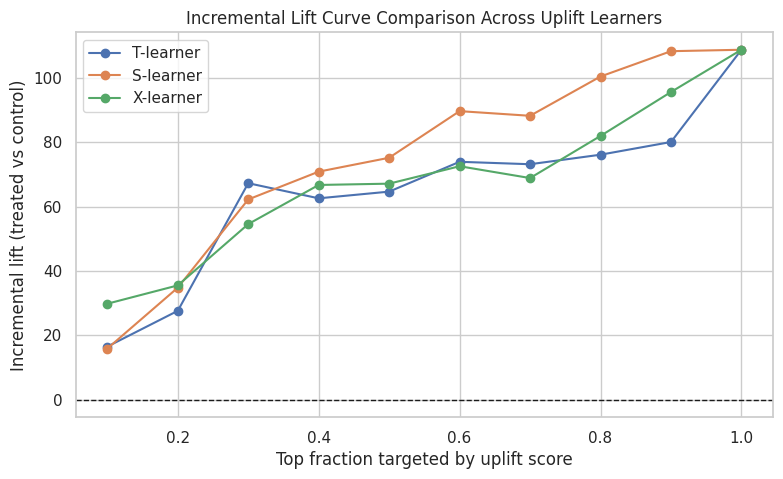

In [64]:
# Overlay lift curves across uplift learners (if available)
plt.figure(figsize=(9, 5))

plotted = 0
if 'uplift_lift_table' in globals() and not uplift_lift_table.empty:
    plt.plot(
        uplift_lift_table['top_fraction'],
        uplift_lift_table['incremental_lift'],
        marker='o',
        label='T-learner',
    )
    plotted += 1

if 's_lift_table' in globals() and not s_lift_table.empty:
    plt.plot(
        s_lift_table['top_fraction'],
        s_lift_table['incremental_lift'],
        marker='o',
        label='S-learner',
    )
    plotted += 1

if 'x_lift_table' in globals() and not x_lift_table.empty:
    plt.plot(
        x_lift_table['top_fraction'],
        x_lift_table['incremental_lift'],
        marker='o',
        label='X-learner',
    )
    plotted += 1

if 'cf_lift_table' in globals() and isinstance(cf_lift_table, pd.DataFrame) and not cf_lift_table.empty:
    plt.plot(
        cf_lift_table['top_fraction'],
        cf_lift_table['incremental_lift'],
        marker='o',
        label='CausalForestDML',
    )
    plotted += 1

if plotted == 0:
    print('No lift tables found. Run Step 11G and Step 11H first.')
else:
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.title('Incremental Lift Curve Comparison Across Uplift Learners')
    plt.xlabel('Top fraction targeted by uplift score')
    plt.ylabel('Incremental lift (treated vs control)')
    plt.legend()
    plt.show()


## Step 12: MLflow Tracking And Model Registry

This section shows how to track the experiment, log metrics and artifacts, and register a model version. For local use, you can keep the file-based tracking URI or point it to a dedicated MLflow server.


In [65]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

mlflow.set_tracking_uri("file:///opt/spark/notebooks/experiments/mlruns")
mlflow.set_experiment("telco-customer-churn")

sample_input = X_test.head(5)
sample_output = lr_model.predict(sample_input)
signature = infer_signature(sample_input, sample_output)

with mlflow.start_run(run_name="logistic-regression-baseline"):
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("threshold", threshold)
    mlflow.log_metric("lr_roc_auc", roc_auc_score(y_test, y_pred_proba_lr))
    mlflow.log_metric("xgb_roc_auc", roc_auc_score(y_test, y_pred_proba_xgb))
    mlflow.log_metric("profit_at_threshold", profit)
    mlflow.log_dict(threshold_results, "artifacts/threshold_scan.json")

    mlflow.sklearn.log_model(
        sk_model=lr_model,
        artifact_path="model",
        signature=signature,
        input_example=sample_input,
        registered_model_name="telco_customer_churn_lr",
    )

print("MLflow run logged. Registered model name: telco_customer_churn_lr")


Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/mlflow/store/tracking/file_store.py", line 327, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/usr/local/lib/python3.8/dist-packages/mlflow/store/tracking/file_store.py", line 421, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/usr/local/lib/python3.8/dist-packages/mlflow/store/tracking/file_store.py", line 1367, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/usr/local/lib/python3.8/dist-packages/mlflow/store/tracking/file_store.py", line 1360, in _read_helper
    result = read_yaml(root, file_name)
  File "/usr/local/lib/python3.8/dist-packages/mlflow/utils/file_utils.py", line 309, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist.")
mlflow.exceptions.MissingConfigException: Yaml file '/opt/spark/notebooks/experiments/mlruns/1/met

MLflow run logged. Registered model name: telco_customer_churn_lr


## Step 13: Weights & Biases

Use this if you want hosted experiment tracking. The W&B dashboard is hosted at [https://wandb.ai](https://wandb.ai), not inside this Docker stack.

Typical flow:
1. Set `WANDB_API_KEY` from a hidden prompt using `getpass`, or export it before starting Jupyter.
2. Start a run with `wandb.init(...)`.
3. Log your churn metrics and business profit.
4. Open the project or run URL printed by the notebook.

Leave this section commented until you are ready to authenticate with your W&B account.


In [66]:
# import wandb
#
# import getpass
# import os
#
# # Capture the API key without echoing it into notebook output.
# if not os.environ.get("WANDB_API_KEY"):
#     os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")
#
# run = wandb.init(
#     project="telco-customer-churn",
#     entity=None,  # Replace with your W&B team or username if needed.
#     job_type="training",
#     tags=["marketing", "churn", "xgboost"],
#     config={
#         "threshold": threshold,
#         "xgb_n_estimators": 200,
#         "xgb_max_depth": 4,
#     },
# )
#
# wandb.log(
#     {
#         "lr_roc_auc": roc_auc_score(y_test, y_pred_proba_lr),
#         "xgb_roc_auc": roc_auc_score(y_test, y_pred_proba_xgb),
#         "xgb_pr_auc": average_precision_score(y_test, y_pred_proba_xgb),
#         "profit": profit,
#     }
# )
#
# print("Project page:", f"https://wandb.ai/{run.entity}/{run.project}")
# print("Run page:", run.url)
#
# wandb.finish()


## Step 14: Evidently Monitoring Snapshot

A lightweight way to generate a data-quality or drift report. Here we compare the training set against the scored test set.


In [67]:
from evidently import Report
from evidently.presets import DataDriftPreset

reference_data = X_train.copy()
current_data = X_test.copy()

drift_report = Report([DataDriftPreset()])
drift_snapshot = drift_report.run(reference_data=reference_data, current_data=current_data)
drift_snapshot.save_html("reports/telco_churn_evidently_report.html")

print("Saved Evidently report to reports/telco_churn_evidently_report.html")


Saved Evidently report to reports/telco_churn_evidently_report.html


## Step 15: WhyLogs And WhyLabs

Use `whylogs` for local logging and optionally send profiles to WhyLabs by configuring your API credentials.


In [68]:
import whylogs as why
from whylogs.api.writer.local import LocalWriter

scored_df = X_test.copy()
scored_df["prediction_score"] = y_pred_proba_xgb
scored_df["prediction_label"] = y_pred

profile = why.log(scored_df).profile()
writer = LocalWriter(base_dir="artifacts", base_name="telco_churn_profile.bin")
writer.write(profile)

print("Saved WhyLogs profile to artifacts/telco_churn_profile.bin")

# Optional WhyLabs upload example
# from whylabs_client import ApiClient, Configuration
# from whylogs.api.writer.whylabs import WhyLabsWriter
#
# writer = WhyLabsWriter()
# writer.write(profile.view())


Saved WhyLogs profile to artifacts/telco_churn_profile.bin


## Step 16: FastAPI Scoring Contract

The local stack now includes a FastAPI starter app on `localhost:8000`. This example payload shows the kind of JSON contract you can build around the churn model.


In [69]:
example_payload = X_test.head(1).to_dict(orient="records")
example_payload


[{'gender': 'Female',
  'SeniorCitizen': 0,
  'Partner': 'Yes',
  'Dependents': 'Yes',
  'tenure': 59,
  'PhoneService': 'Yes',
  'MultipleLines': 'No',
  'InternetService': 'DSL',
  'OnlineSecurity': 'No',
  'OnlineBackup': 'Yes',
  'DeviceProtection': 'No',
  'TechSupport': 'Yes',
  'StreamingTV': 'Yes',
  'StreamingMovies': 'Yes',
  'Contract': 'Two year',
  'PaperlessBilling': 'Yes',
  'PaymentMethod': 'Credit card (automatic)',
  'MonthlyCharges': 75.95,
  'TotalCharges': 4542.35}]

In [70]:
# import requests
# response = requests.post("http://localhost:8000/predict", json=example_payload)
# response.json()


## Final Story

I built a churn prediction workflow for a marketing retention use case and linked model outputs to business action.

- Started with **Logistic Regression** as an interpretable baseline, then trained **XGBoost** for stronger nonlinear performance.
- Handled class imbalance explicitly using **`scale_pos_weight`**, and evaluated with both **ROC-AUC** and **PR-AUC**.
- Improved probability quality with **calibration** (isotonic) and validated with **Brier score** + calibration curve.
- Optimized decision thresholds with a **business cost/profit framework** instead of default `0.5`.
- Added **risk segmentation** to measure how many churners are captured in the top 20% highest-risk customers.
- Used **SHAP** and feature importance for explainability, and documented **leakage checks** plus **train-test AUC gap** for overfitting control.
- Added **uplift modeling (T-learner)** to estimate incremental treatment effect and prioritize customers most likely to change behavior with outreach.
- Benchmarked multiple uplift approaches (**T-learner, S-learner, X-learner, and optional causal forest**) to estimate incremental treatment effect under budget constraints.

This turns churn modeling from a pure prediction task into an operational retention strategy.
